# ANÁLISIS DE CLÚSTERES LIBERE - RETO 06 AMARILLO

- Cargar e importar librerías

In [1]:
%matplotlib inline
from sklearn.datasets import make_blobs
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering

import seaborn as sns
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

- Cargar datos

In [4]:
path = os.path.join('Datos', 'Transformados', 'df_limpio_con_clusters.csv')
df = pd.read_csv(path)

In [49]:
#Separar columnas numéricas y categóricas
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

DISTRIBUCIÓN DE CANCELACIONES POR CLÚSTER

C:\Users\gabov\AppData\Local\Temp\ipykernel_24396\256272253.py:8: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.countplot(data=df, x='cluster_kmeans_3', hue='status', palette = paleta)


<Figure size 1500x2000 with 0 Axes>

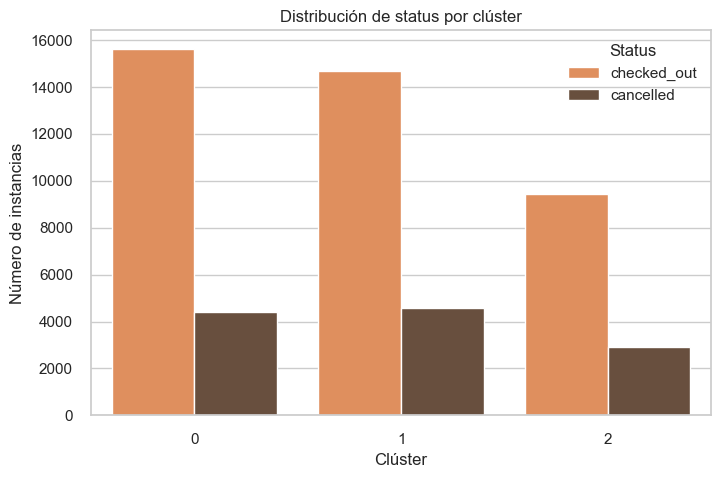

In [57]:
#Paleta personalizada
paleta = ["#F48A48", "#6F4E37", "#EBB68D", "#391704", "#FF4704"]
#Configuración general de los gráficos
sns.set(style="whitegrid")
plt.figure(figsize=(15, 20))

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='cluster_kmeans_3', hue='status', palette = paleta)
plt.title('Distribución de status por clúster')
plt.xlabel('Clúster')
plt.ylabel('Número de instancias')
plt.legend(title='Status')
plt.show()

In [52]:
#Porcentajes de cancelaciones por clúster
status_prop = (
    df
    .groupby('cluster_kmeans_3')['status']
    .value_counts(normalize=True)
    .rename('proportion')
    .reset_index()
)

status_prop

,cluster_kmeans_3,status,proportion
0,0,checked_out,0.779412
1,0,cancelled,0.220588
2,1,checked_out,0.762431
3,1,cancelled,0.237569
4,2,checked_out,0.764401
5,2,cancelled,0.235599


PERFIL MEDIO POR CLÚSTER

In [55]:
perfil_cluster_num = (
    df
    .groupby('cluster_kmeans_3')[num_cols]
    .mean()
)
perfil_cluster_num

print("PERFIL MEDIO POR CLÚSTER")
print(perfil_cluster_num.to_string())

PERFIL MEDIO POR CLÚSTER
                  lead_time  lenght_of_stay  adult_count  child_count  available_units  completed_entry_forms_count  recurrence  product_count  reservation_net_value   total_adr  cancellation_lead_time  zona_roja_mes  total_personas_adult_y_niños  ratio_formularios  reservation_checkin_month_diff  estancia_en_festivo  estancia_en_finde  mes_checkin_numerico  cluster_kmeans_3
cluster_kmeans_3                                                                                                                                                                                                                                                                                                                                                                         
0                 31.366451        1.929262     1.686142     0.200548       131.525474                     1.128116    1.468843       0.528564             103.932629   60.184359                4.319392       0.256331   

In [73]:
#Paleta personalizada
paleta = ["#F48A48", "#6F4E37", "#EBB68D", "#391704", "#FF4704"]
#Configuración general de los gráficos
sns.set(style="white")

C:\Users\gabov\AppData\Local\Temp\ipykernel_24396\3042840222.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\gabov\AppData\Local\Temp\ipykernel_24396\3042840222.py:8: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.barplot(


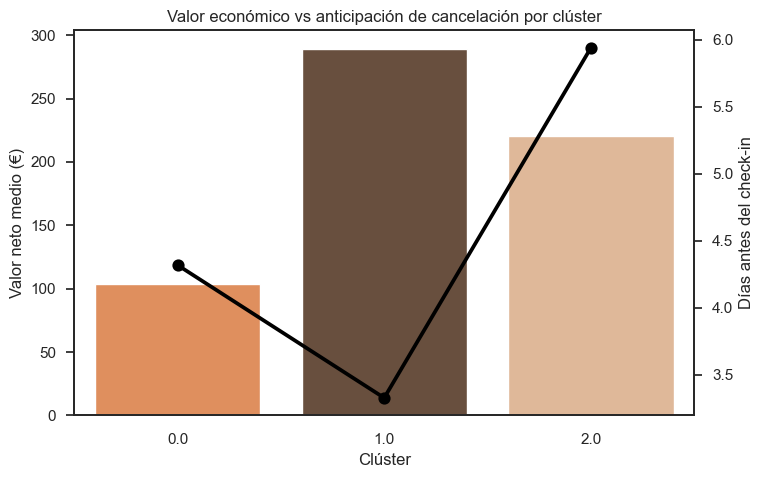

In [74]:
df_clusters = (
    df
    .groupby('cluster_kmeans_3')[num_cols]
    .mean()
)

fig, ax1 = plt.subplots(figsize=(8,5))
sns.barplot(
    data=df_clusters,
    x='cluster_kmeans_3',
    y='reservation_net_value',
    palette=paleta,
    ax=ax1,
    errorbar=None
)

ax1.set_ylabel('Valor neto medio (€)')
ax1.set_xlabel('Clúster')
ax1.yaxis.grid(False)

ax2 = ax1.twinx()
sns.pointplot(
    data=df_clusters,
    x='cluster_kmeans_3',
    y='cancellation_lead_time',
    color='black',
    ax=ax2
)

ax2.set_ylabel('Días antes del check-in')
ax2.yaxis.grid(False)

plt.title('Valor económico vs anticipación de cancelación por clúster')
plt.show()

GRÁFICO RADAR: PERFIL NORMALIZADO DE LOS CLÚSTERES

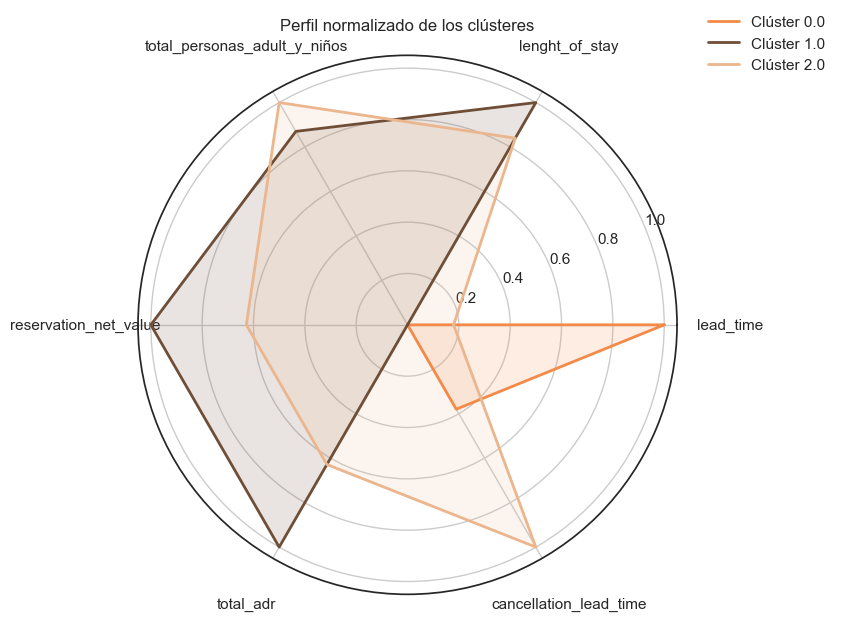

In [ ]:
variables_radar = [
    'lead_time',
    'lenght_of_stay',
    'total_personas_adult_y_niños',
    'reservation_net_value',
    'total_adr',
    'cancellation_lead_time'
]

df_radar = df_clusters[['cluster_kmeans_3'] + variables_radar]
df_norm = df_radar.copy()

#Normalización 0-1
for v in variables_radar:
    df_norm[v] = (df_norm[v] - df_norm[v].min()) / (df_norm[v].max() - df_norm[v].min())

labels = variables_radar
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)

#Iterar por clúster con color
for i, c in enumerate(df_norm['cluster_kmeans_3'].unique()):
    values = (
        df_norm[df_norm['cluster_kmeans_3'] == c][labels]
        .values
        .flatten()
        .tolist()
    )
    values += values[:1]

    color = paleta[i % len(paleta)]  # por seguridad si hay más clusters

    ax.plot(
        angles,
        values,
        label=f'Clúster {c}',
        color=color,
        linewidth=2
    )
    ax.fill(
        angles,
        values,
        color=color,
        alpha=0.15
    )

ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.tick_params(pad=25)
plt.title('Perfil normalizado de los clústeres')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

- Filtrar datos por cluster

In [29]:
cluster_0 = df[df['cluster_kmeans_3'] == 0]
cluster_1 = df[df['cluster_kmeans_3'] == 1]
cluster_2 = df[df['cluster_kmeans_3'] == 2]

- Gráficos para el clúster 0

C:\Users\gabov\AppData\Local\Temp\ipykernel_24396\1224037466.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\gabov\AppData\Local\Temp\ipykernel_24396\1224037466.py:17: UserWarning: 
The palette list has fewer values (5) than needed (12) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(
C:\Users\gabov\AppData\Local\Temp\ipykernel_24396\1224037466.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\gabov\AppData\Local\Temp\ipykernel_24396\1224037466.py:27: UserWarning: 
The palette list has fewer values (5) than needed (11) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(
C:\Users\gabov\AppData\Local\Temp\ipyk

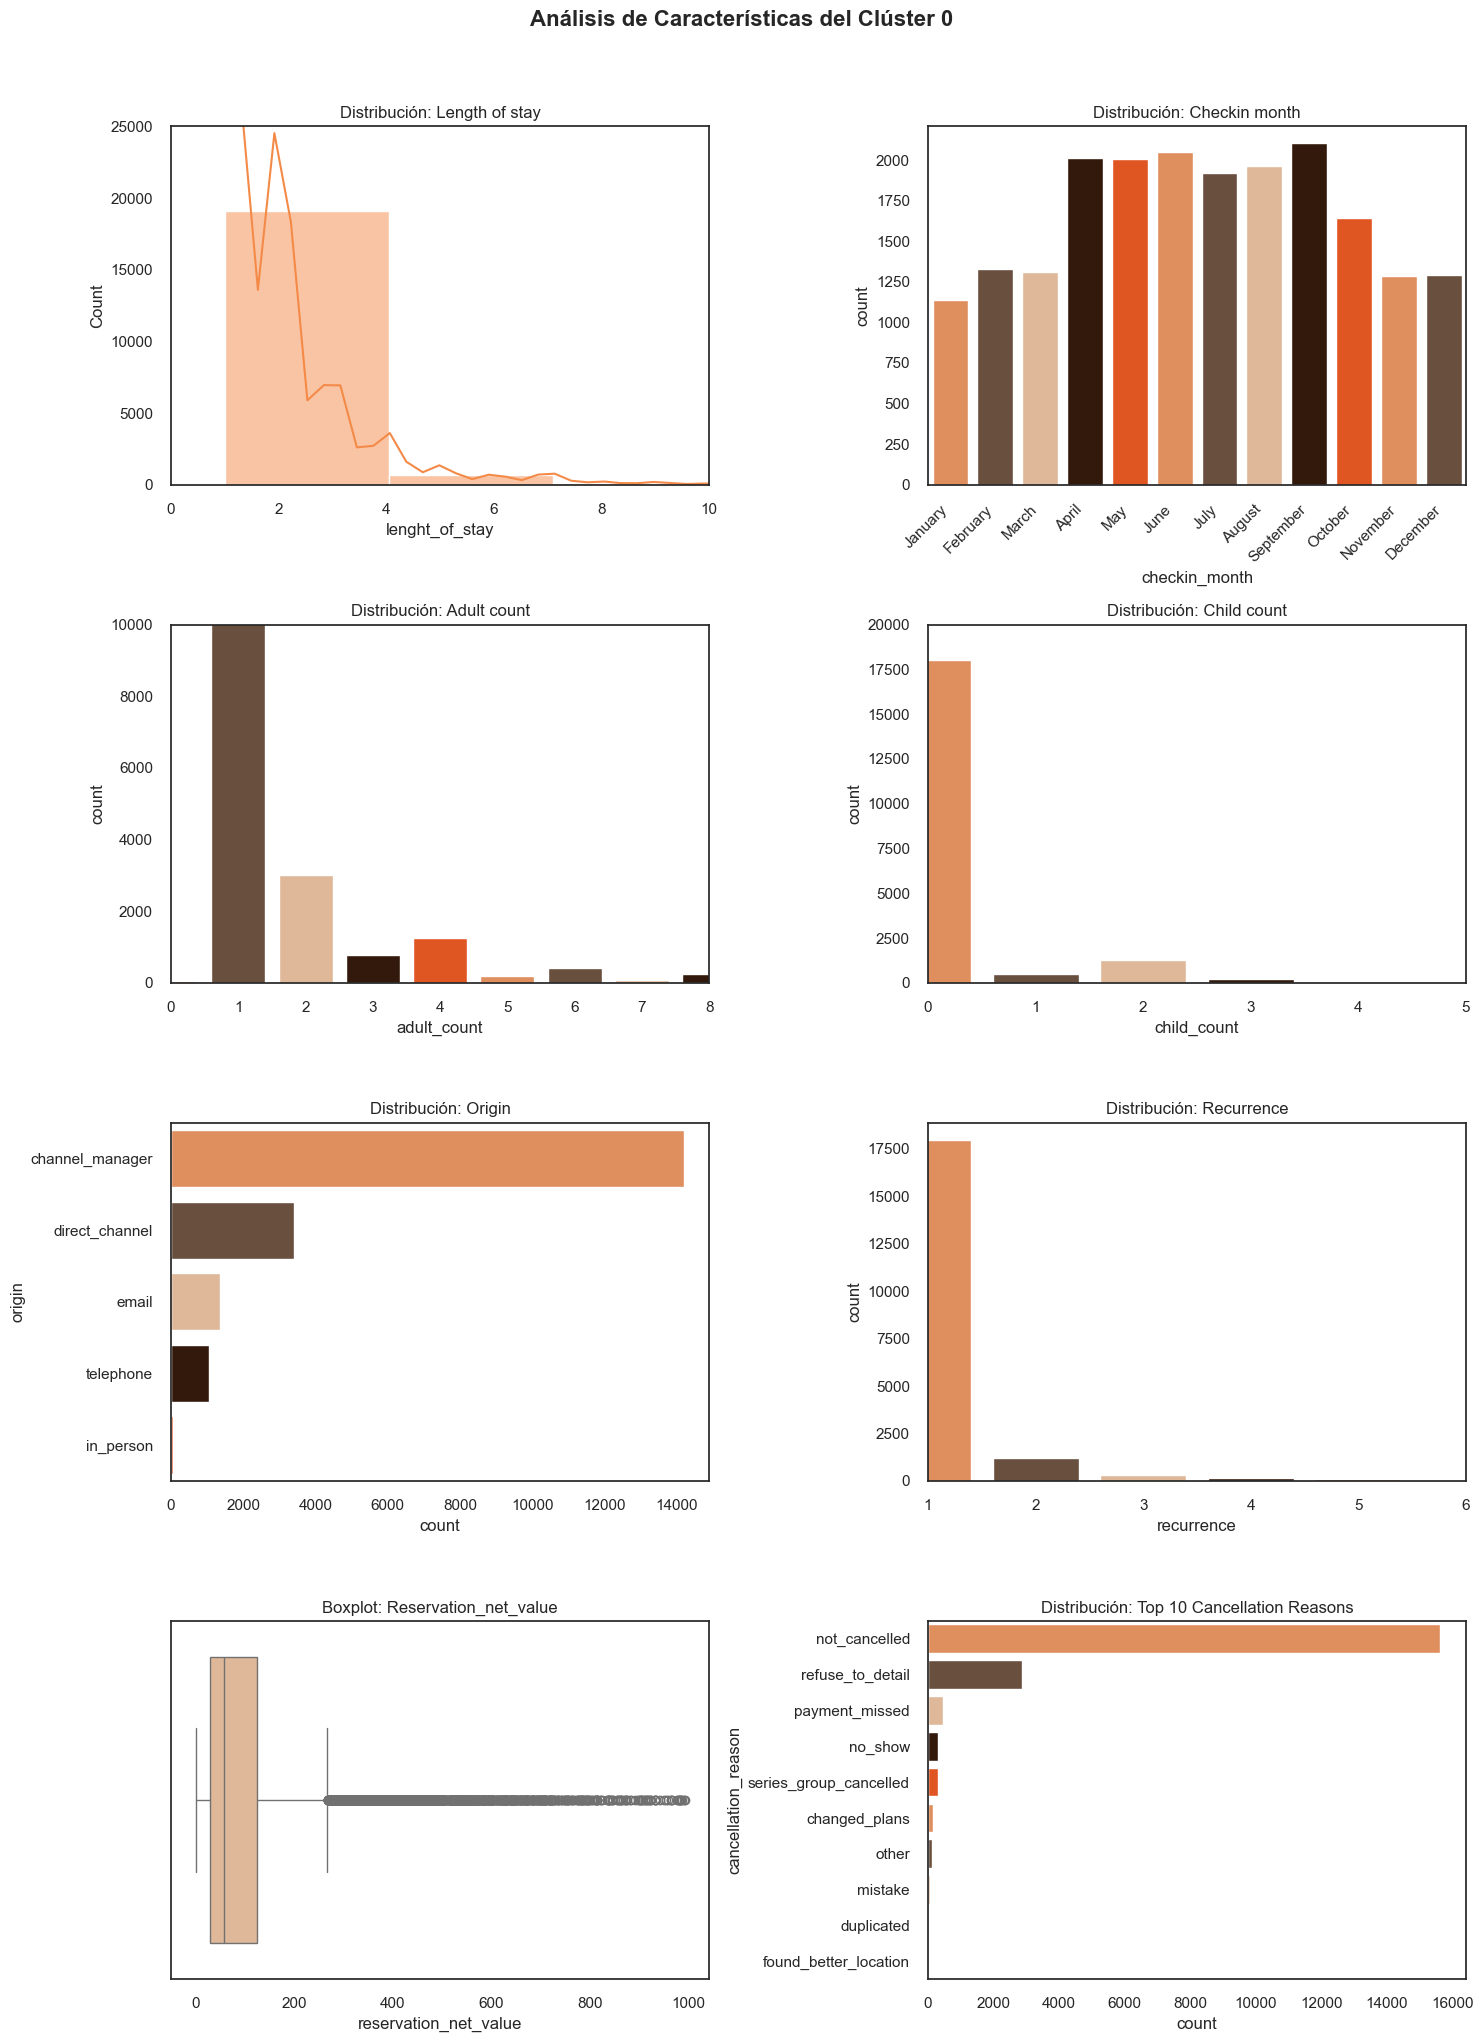

In [75]:
plt.figure(figsize=(15, 20))

# 1. Length of stay
plt.subplot(4, 2, 1)
sns.histplot(
    cluster_0['lenght_of_stay'],
    bins=20,
    kde=True,
    color=paleta[0]
)
plt.title('Distribución: Length of stay')
plt.xlim(0, 10)
plt.ylim(0, 25000)

# 2. Checkin month
plt.subplot(4, 2, 2)
sns.countplot(
    x='checkin_month',
    data=cluster_0,
    palette=paleta
)
plt.title('Distribución: Checkin month')
plt.xticks(rotation=45, ha='right')

# 3. Adult count
plt.subplot(4, 2, 3)
sns.countplot(
    x='adult_count',
    data=cluster_0,
    palette=paleta
)
plt.title('Distribución: Adult count')
plt.xlim(0, 8)
plt.ylim(0, 10000)

# 4. Child count
plt.subplot(4, 2, 4)
sns.countplot(
    x='child_count',
    data=cluster_0,
    palette=paleta
)
plt.title('Distribución: Child count')
plt.xlim(0, 5)
plt.ylim(0, 20000)

# 5. Origin
plt.subplot(4, 2, 5)
sns.countplot(
    y='origin',
    data=cluster_0,
    order=cluster_0['origin'].value_counts().index,
    palette=paleta
)
plt.title('Distribución: Origin')

# 6. Recurrence
plt.subplot(4, 2, 6)
sns.countplot(
    x='recurrence',
    data=cluster_0,
    palette=paleta
)
plt.title('Distribución: Recurrence')
plt.xlim(0, 5)

# 7. Reservation_net_value
plt.subplot(4, 2, 7)
sns.boxplot(
    x='reservation_net_value',
    data=cluster_0,
    color=paleta[2]
)
plt.title('Boxplot: Reservation_net_value')

# 8. Cancellation reason
plt.subplot(4, 2, 8)
# Mostrar solo las 10 razones más frecuentes
top_reasons = cluster_0['cancellation_reason'].value_counts().nlargest(10).index
sns.countplot(y='cancellation_reason', data=cluster_0,
              order=top_reasons,
              palette=paleta)
plt.title('Distribución: Top 10 Cancellation Reasons')

plt.suptitle('Análisis de Características del Clúster 0', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

- Gráficos para el clúster 1

C:\Users\gabov\AppData\Local\Temp\ipykernel_24396\514454189.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='checkin_month', data=cluster_1, palette=paleta)
C:\Users\gabov\AppData\Local\Temp\ipykernel_24396\514454189.py:16: UserWarning: 
The palette list has fewer values (5) than needed (12) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(x='checkin_month', data=cluster_1, palette=paleta)
C:\Users\gabov\AppData\Local\Temp\ipykernel_24396\514454189.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='adult_count', data=cluster_1, palette=paleta)
C:\Users\gabov\AppData\Local\Temp\ipykernel_24396\514454189.py:23: UserWarning: 
The palette list has fewe

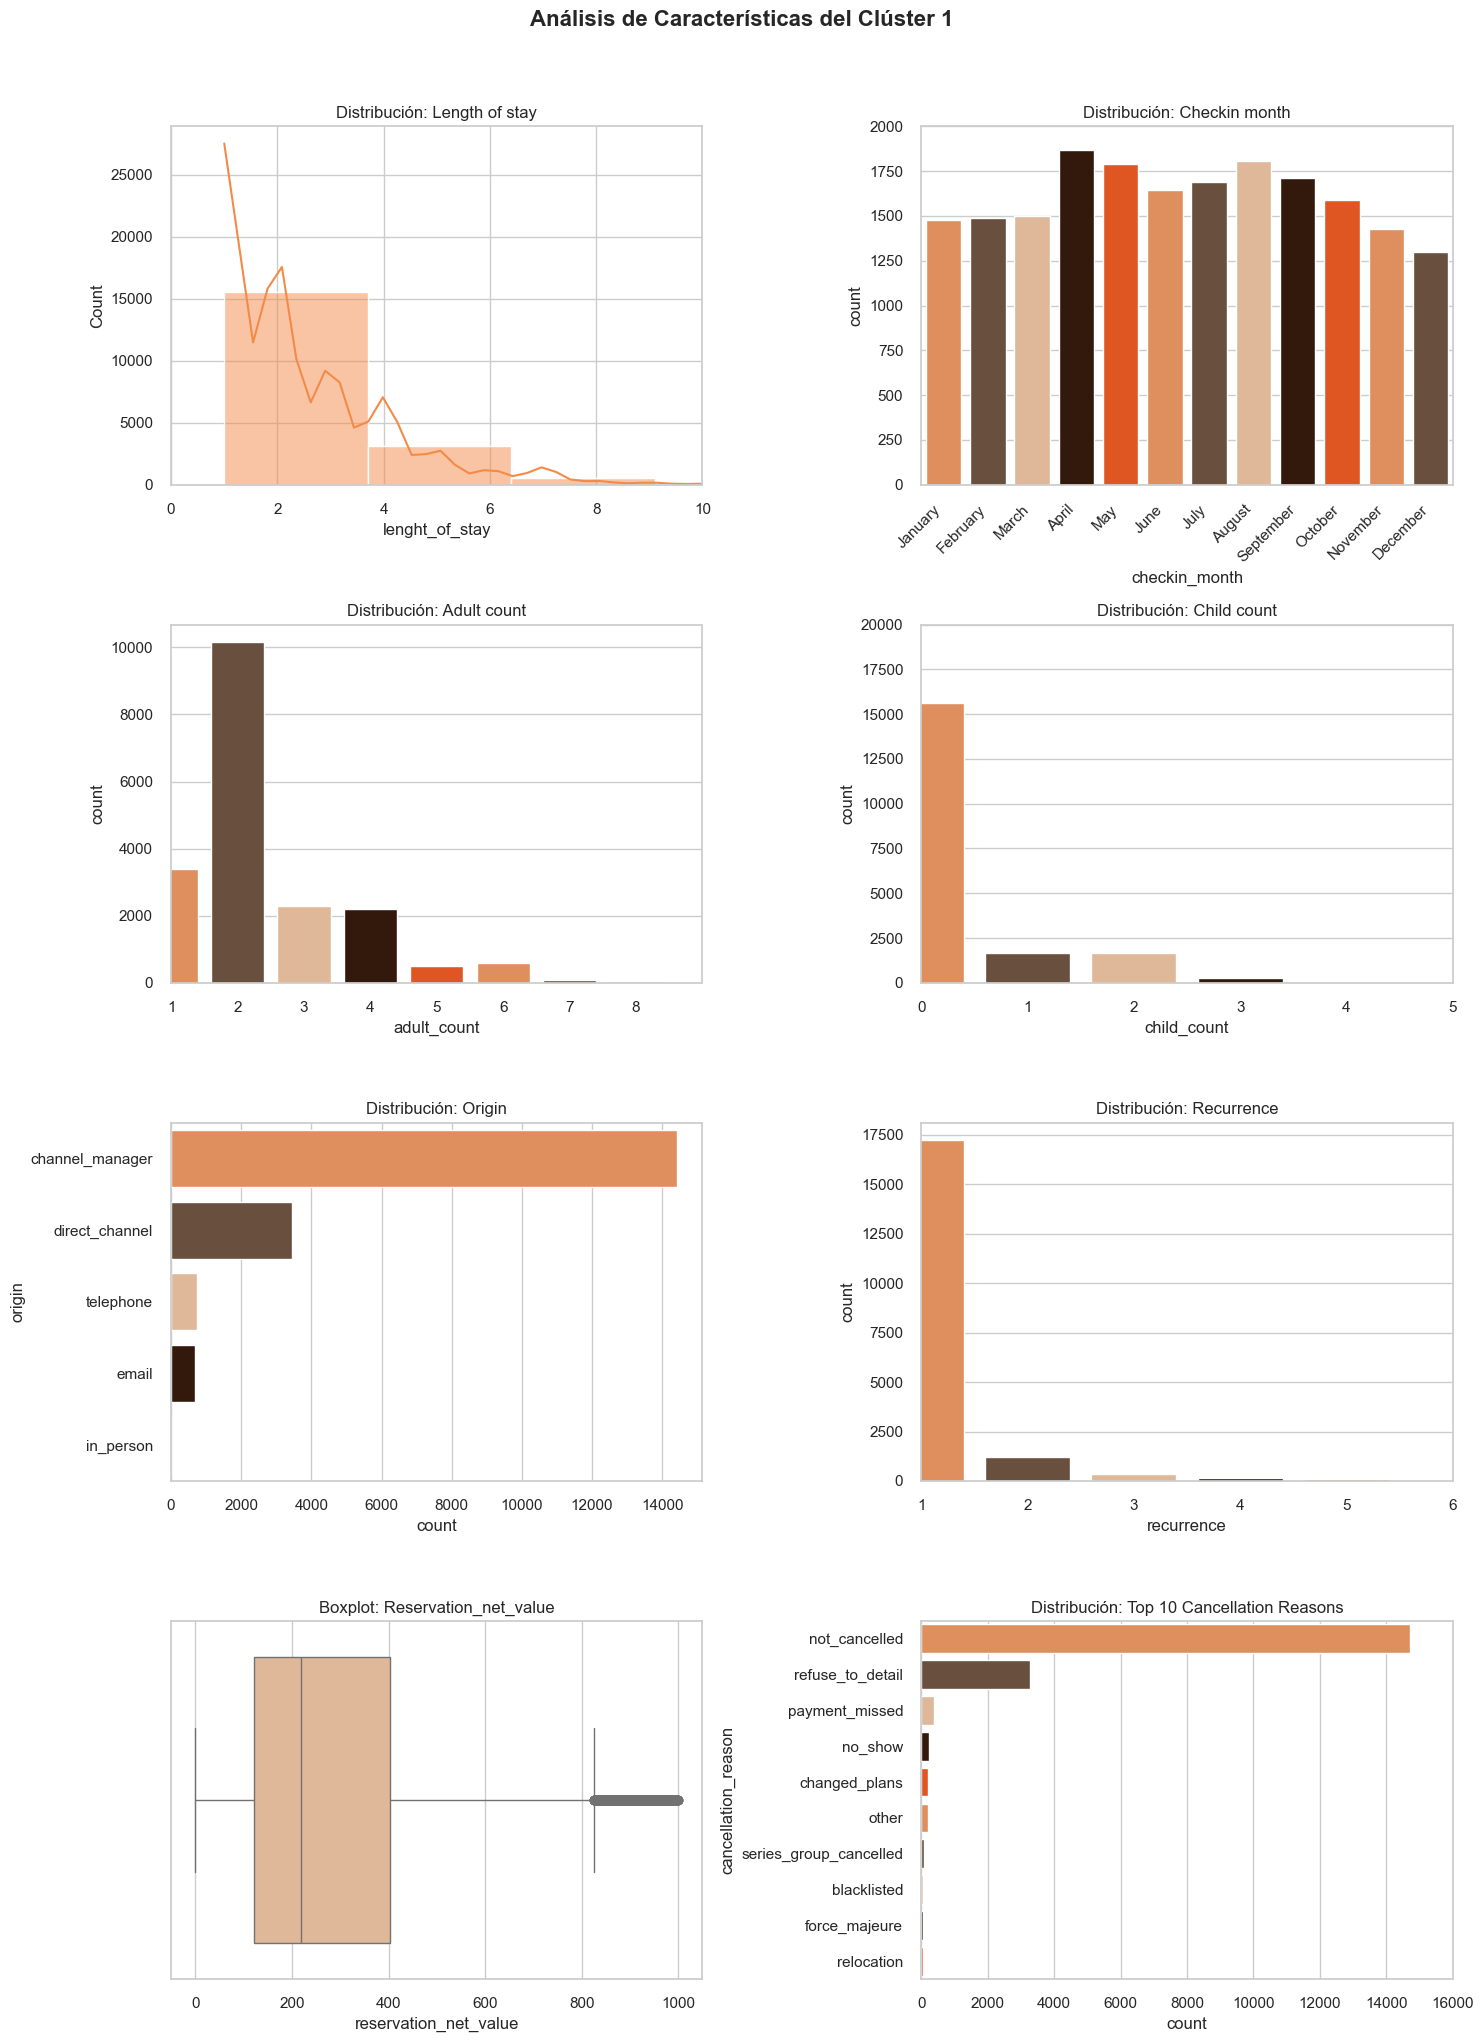

In [ ]:
plt.figure(figsize=(15, 20))

# 1. Length of stay
plt.subplot(4, 2, 1)
sns.histplot(cluster_1['lenght_of_stay'], bins=20, kde=True, color = paleta[0])
plt.title('Distribución: Length of stay')
plt.xlim(0, 10)

# 2. Checkin month
plt.subplot(4, 2, 2)
sns.countplot(x='checkin_month', data=cluster_1, palette=paleta)
plt.title('Distribución: Checkin month')
plt.ylim(0, 2000)
plt.xticks(rotation=45, ha='right')

# 3. Adult count
plt.subplot(4, 2, 3)
sns.countplot(x='adult_count', data=cluster_1, palette=paleta)
plt.title('Distribución: Adult count')
plt.xlim(0, 8)

# 4. Child count
plt.subplot(4, 2, 4)
sns.countplot(x='child_count', data=cluster_1, palette=paleta)
plt.title('Distribución: Child count')
plt.xlim(0, 5)
plt.ylim(0, 20000)

# 5. Origin
plt.subplot(4, 2, 5)
sns.countplot(y='origin', data=cluster_1, order=cluster_1['origin'].value_counts().index, palette=paleta)
plt.title('Distribución: Origin')

# 6. Recurrence
plt.subplot(4, 2, 6)
sns.countplot(x='recurrence', data=cluster_1, palette=paleta)
plt.title('Distribución: Recurrence')
plt.xlim(0, 5)

# 7. Reservation_net_value
plt.subplot(4, 2, 7)
sns.boxplot(x='reservation_net_value', data=cluster_1, color=paleta[2])
plt.title('Boxplot: Reservation_net_value')

# 8. Cancellation reason
plt.subplot(4, 2, 8)
# Mostrar solo las 10 razones más frecuentes
top_reasons = cluster_1['cancellation_reason'].value_counts().nlargest(10).index
sns.countplot(y='cancellation_reason', data=cluster_1,
              order=top_reasons,
              palette=paleta)
plt.title('Distribución: Top 10 Cancellation Reasons')
plt.xlim(0, 16000)

plt.suptitle('Análisis de Características del Clúster 1', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

- Gráficos para el clúster 2

C:\Users\gabov\AppData\Local\Temp\ipykernel_24396\1701754049.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='checkin_month', data=cluster_2, palette=paleta)
C:\Users\gabov\AppData\Local\Temp\ipykernel_24396\1701754049.py:17: UserWarning: 
The palette list has fewer values (5) than needed (12) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(x='checkin_month', data=cluster_2, palette=paleta)
C:\Users\gabov\AppData\Local\Temp\ipykernel_24396\1701754049.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\gabov\AppData\Local\Temp\ipykernel_24396\1701754049.py:24: UserWarning: 
The palette list has fewer values (5) than needed (7) and will cycle,

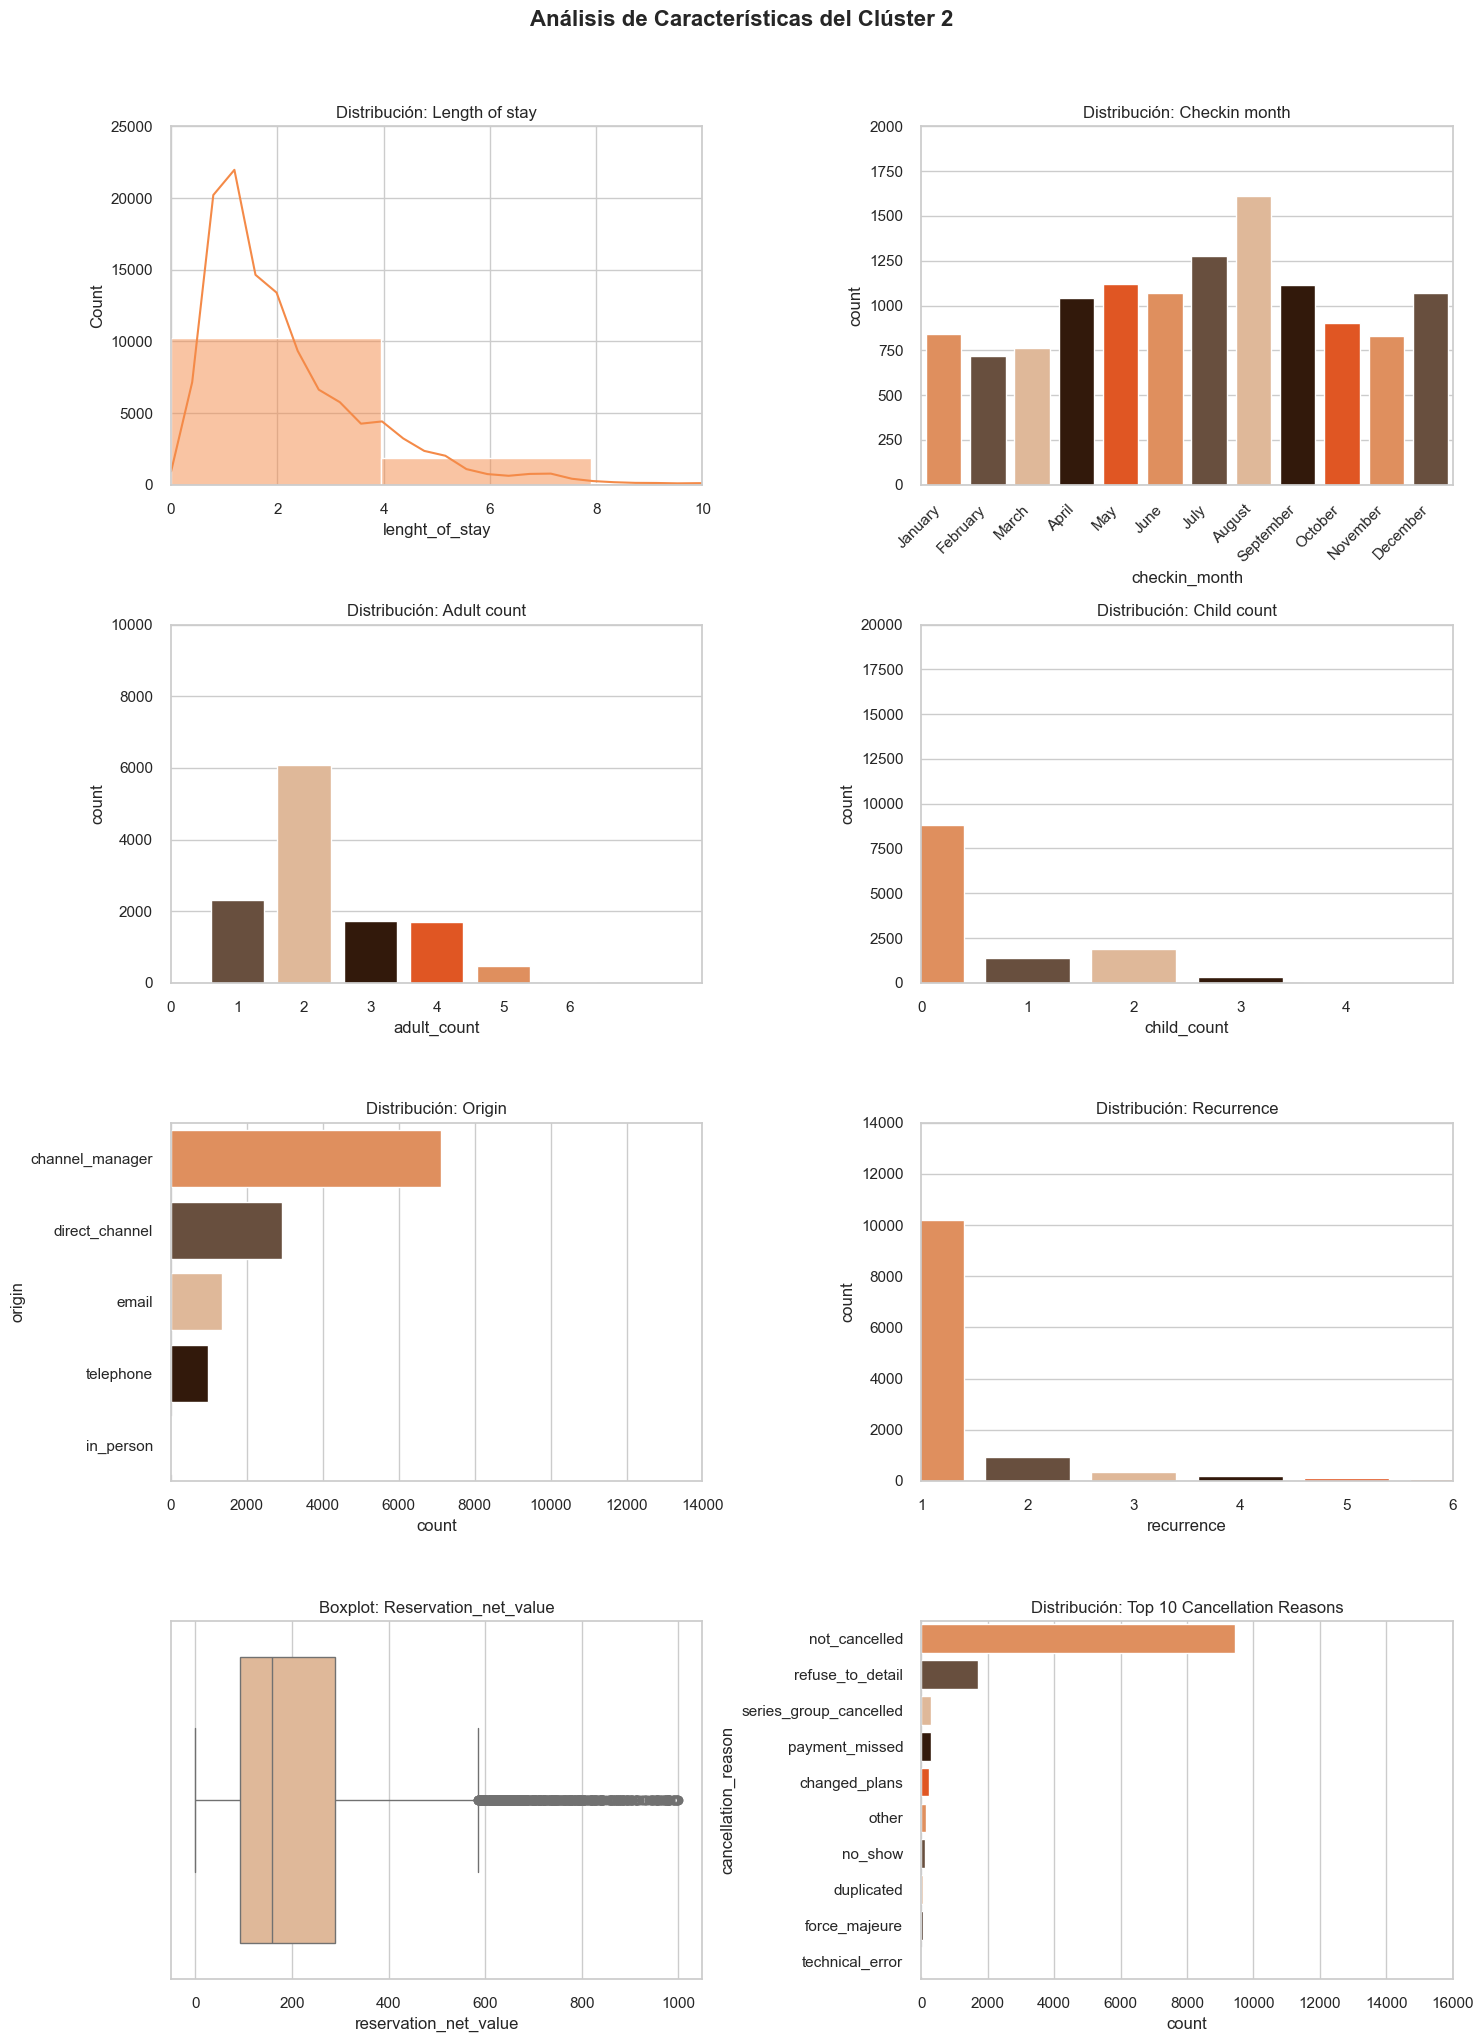

In [72]:
plt.figure(figsize=(15, 20))

# 1. Length of stay
plt.subplot(4, 2, 1)
sns.histplot(
    cluster_2['lenght_of_stay'],
    bins=20,
    kde=True,
    color=paleta[0]
)
plt.title('Distribución: Length of stay')
plt.xlim(0, 10)
plt.ylim(0, 25000)

# 2. Checkin month
plt.subplot(4, 2, 2)
sns.countplot(x='checkin_month', data=cluster_2, palette=paleta)
plt.title('Distribución: Checkin month')
plt.ylim(0, 2000)
plt.xticks(rotation=45, ha='right')

# 4. Adult count
plt.subplot(4, 2, 3)
sns.countplot(
    x='adult_count',
    data=cluster_2,
    palette=paleta
)
plt.title('Distribución: Adult count')
plt.xlim(0, 8)
plt.ylim(0, 10000)

# 5. Child count
plt.subplot(4, 2, 4)
sns.countplot(
    x='child_count',
    data=cluster_2,
    palette=paleta
)
plt.title('Distribución: Child count')
plt.xlim(0, 5)
plt.ylim(0, 20000)

# 6. Origin
plt.subplot(4, 2, 5)
sns.countplot(
    y='origin',
    data=cluster_2,
    order=cluster_2['origin'].value_counts().index,
    palette=paleta
)
plt.title('Distribución: Origin')
plt.xlim(0, 14000)

# 7. Recurrence
plt.subplot(4, 2, 6)
sns.countplot(
    x='recurrence',
    data=cluster_2,
    palette=paleta
)
plt.title('Distribución: Recurrence')
plt.xlim(0, 5)
plt.ylim(0, 14000)

# 8. Reservation net value
plt.subplot(4, 2, 7)
sns.boxplot(
    x='reservation_net_value',
    data=cluster_2,
    color=paleta[2]
)
plt.title('Boxplot: Reservation_net_value')

# 8. Cancellation reason
plt.subplot(4, 2, 8)
# Mostrar solo las 10 razones más frecuentes
top_reasons = cluster_2['cancellation_reason'].value_counts().nlargest(10).index
sns.countplot(y='cancellation_reason', data=cluster_2,
              order=top_reasons,
              palette=paleta)
plt.title('Distribución: Top 10 Cancellation Reasons')
plt.xlim(0, 16000)

plt.suptitle('Análisis de Características del Clúster 2', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()